### TO DO

- Create parts of speech tags

- plot the most frequent unigram (token) for each timeline

- show the most freq unigrams POS

- show the most freq unigrams NER

- Plot bigrams and trigrams for each timeline

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import random
import time
from tqdm.notebook import tqdm
import arabic_reshaper
from bidi.algorithm import get_display

# Shekar
from shekar import POSTagger, NER, WordTokenizer

# NLTK
from nltk import ngrams
import nltk
nltk.download('punkt_tab', quiet = True)

print('Done.')

Done.


[nltk_data] Error loading punkt_tab: <urlopen error [Errno 111]
[nltk_data]     Connection refused>


In [68]:
# Plot settings
sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

In [69]:
# Load the data
df = pd.read_csv('../data/preprocessed/all_processed.csv', encoding = 'utf-8-sig')

In [70]:
# Convert string lists to actual lists
for col in ['tokens', 'tokens_persian', 'tokens_stemmed', 'final_tokens_sent', 'final_tokens_freq', 'final_tokens_freq_stemmed', 'final_tokens_freq_not_stemmed']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11174 entries, 0 to 11173
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   message_id                     11174 non-null  int64 
 1   cleaned_text                   11174 non-null  str   
 2   timeline                       11174 non-null  str   
 3   normalized                     11174 non-null  str   
 4   tokens                         11174 non-null  object
 5   tokens_persian                 11174 non-null  object
 6   tokens_stemmed                 11174 non-null  object
 7   final_tokens_sent              11174 non-null  object
 8   final_tokens_freq_stemmed      11174 non-null  object
 9   final_tokens_freq_not_stemmed  11174 non-null  object
dtypes: int64(1), object(6), str(3)
memory usage: 6.0+ MB


In [71]:
df.head(2)

,message_id,cleaned_text,timeline,normalized,tokens,tokens_persian,tokens_stemmed,final_tokens_sent,final_tokens_freq_stemmed,final_tokens_freq_not_stemmed
0,129507,تنها کسی که تو مملکت داره کارش رو خوب انجام می...,timeline_1,تنها کسی که تو مملکت داره کارش رو خوب انجام می...,"[تنها, کسی, که, تو, مملکت, داره, کارش, رو, خوب...","[تنها, کسی, که, تو, مملکت, داره, کارش, رو, خوب...","[تنها, کسی, که, تو, مملک, داره, کار, را, خوب, ...","[کسی, مملک, خوب, انجا, چسب, زن, الویه, نامینو,...","[مملک, انجا, چسب, زن, الویه, نامینو, دادا, یکم...","[مملکت, کارش, انجام, چسب, زن, الویه, نامینو, د..."
1,129512,اولین سالی که بابانوئل برای بچه‌های ما چیزی آو...,timeline_1,اولین سالی که بابانوئل برای بچه‌های ما چیزی آو...,"[اولین, سالی, که, بابانوئل, برای, بچه‌های, ما,...","[اولین, سالی, که, بابانوئل, برای, بچه‌های, ما,...","[اولین, سال, که, بابانوئل, برا, بچه, ما, چیز, ...","[اولین, بابانوئل, آورد, فکر, واکن, دختر, صبح, ...","[بابانوئل, آورد, فکر, واکن, دختر, صبح, بیدار, ...","[سالی, بابانوئل, بچه‌های, آورد, فکر, واکنش, دخ..."


In [72]:
# Top 50 words per timeline
TOP_N_WORDS = 50
TOP_WORDS_PRE_TL = {}
all_top_words = set()

for tl in sorted(df['timeline'].unique()):
    tdf = df[df['timeline'] == tl]

    all_tokens = [tok for tokens in tdf['final_tokens_freq_stemmed'] for tok in tokens]
    cnt = Counter(all_tokens)
    top = cnt.most_common(TOP_N_WORDS)
    top_words = [word for word, _ in top]
    TOP_WORDS_PRE_TL[tl] = top_words
    all_top_words.update(top_words)
    
    print(f'{tl}: top 10 words: {top_words[:10]}')

timeline_1: top 10 words: ['زندگی', 'بابا', 'مامان', 'خانه', 'دختر', 'پسر', 'فکر', 'درس', 'مرد', 'آدم']
timeline_2: top 10 words: ['زندگی', 'ایران', 'آدم', 'درس', 'مرد', 'فکر', 'خرید', 'جنگ', 'خانه', 'پول']
timeline_3: top 10 words: ['زندگی', 'ایران', 'اینترنت', 'فکر', 'مرد', 'خانه', 'جنگ', 'آدم', 'بابا', 'پسر']


In [73]:
# Persian font fix for display
def reshape_persian(text):
    '''
    Reshape Persian text so it displays correctly
    '''
    if not isinstance(text, str):
        return text
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

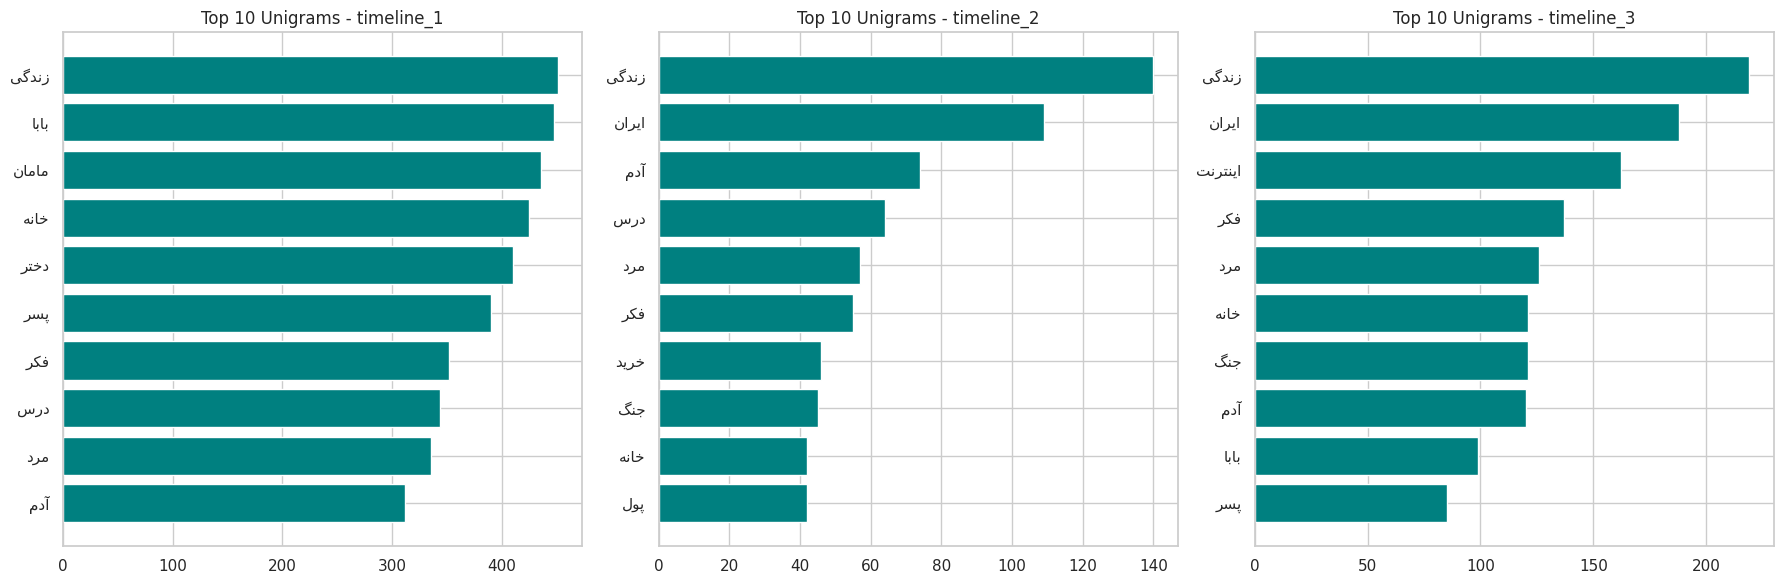

In [ ]:
# Plot most frequent words per timeline
fig, axes = plt.subplots(1, 3, figsize = (18, 6))

for idx, tl in enumerate(sorted(df['timeline'].unique())):
    tdf = df[df['timeline'] == tl]
    all_tokens = [tok for tokens in tdf['final_tokens_freq_stemmed'] for tok in tokens]
    cnt = Counter(all_tokens)
    top_itmes = cnt.most_common(10)
    words, freqs = zip(*top_itmes) if top_itmes else ([], [])

    # Reshape
    reshaped_words = [reshape_persian(w) for w in words]

    ax = axes[idx]
    ax.barh(reshaped_words, freqs, color = 'teal')
    ax.set_title(f'Top 10 Unigrams - {tl}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [52]:
# Sample for top sentences 
MAX_SAMPLES_PER_WORD = 21
word_samples = {word: [] for word in all_top_words}

for idx, row in df.iterrows():
    text = row['normalized']
    if not isinstance(text, str) or text.strip() == '':
        continue
    tokens = text.split()
    for word in all_top_words:
        if word in tokens and len(word_samples[word]) < MAX_SAMPLES_PER_WORD:
            word_samples[word].append(text)
    if all(len(v) >= MAX_SAMPLES_PER_WORD for v in word_samples.values()):
        break

for word in all_top_words:
    print(f'{word}: {len(word_samples[word])} samples.')

سر: 21 samples.
حرف: 21 samples.
دانشجو: 21 samples.
دختر: 21 samples.
کیر: 21 samples.
پسر: 21 samples.
استفاده: 21 samples.
گران: 4 samples.
اینترنت: 21 samples.
تومان: 21 samples.
مرد: 21 samples.
ازدواج: 21 samples.
کانفیگ: 21 samples.
زن: 21 samples.
آدم: 21 samples.
دانشگاه: 21 samples.
ترامپ: 21 samples.
صدا: 21 samples.
داشت: 21 samples.
زد: 21 samples.
نسل: 21 samples.
چپ: 21 samples.
فکر: 21 samples.
ماه: 21 samples.
جلو: 21 samples.
تجربه: 21 samples.
کشور: 21 samples.
ماشین: 21 samples.
صبح: 21 samples.
دقیقه: 21 samples.
آموز: 0 samples.
جواب: 21 samples.
بابا: 21 samples.
زمان: 21 samples.
هزینه: 21 samples.
رابطه: 21 samples.
زبان: 21 samples.
خانه: 19 samples.
تهران: 21 samples.
بزرگ: 21 samples.
گریه: 21 samples.
هوش: 21 samples.
وضعی: 2 samples.
هفته: 21 samples.
دلم: 21 samples.
مادر: 21 samples.
یاد: 21 samples.
روان: 21 samples.
رایگان: 21 samples.
راه: 21 samples.
وصل: 21 samples.
تلگرام: 21 samples.
دوست: 21 samples.
انسان: 21 samples.
زنده: 21 samples.
اقتصاد: 2

In [53]:
# POS and NER on samples
post_tagger = POSTagger()
ner_model = NER()

def batch_process(func, texts, batch_size = 100, sleep_sec = 2.0, desc = 'Processing'):
    results = []
    for start in tqdm(range(0, len(texts), batch_size), desc = desc):
        batch = texts[start:start + batch_size]
        batch_results = [func(t) for t in batch]
        results.extend(batch_results)
        if start + batch_size < len(texts):
            time.sleep(sleep_sec)
    return results

In [56]:
# Unique samples texts
all_samples_texts = list(set(text for samples in word_samples.values() for text in samples))

# POS
pos_results = batch_process(
    lambda t: post_tagger(t[:400]) if isinstance(t, str) and t.strip() else [],
    all_samples_texts, batch_size = 100, sleep_sec = 2.0, desc = 'POS Tagging'
)

text_to_pos = dict(zip(all_samples_texts, pos_results))

POS Tagging:   0%|          | 0/12 [00:00<?, ?it/s]

In [57]:
# NER 
ner_results = batch_process(
    lambda t: ner_model(t[:400]) if isinstance(t, str) and t.strip() else [],
    all_samples_texts, batch_size = 100, sleep_sec = 2.0, desc = 'NER'
)

text_to_ner = dict(zip(all_samples_texts, ner_results))

NER:   0%|          | 0/12 [00:00<?, ?it/s]

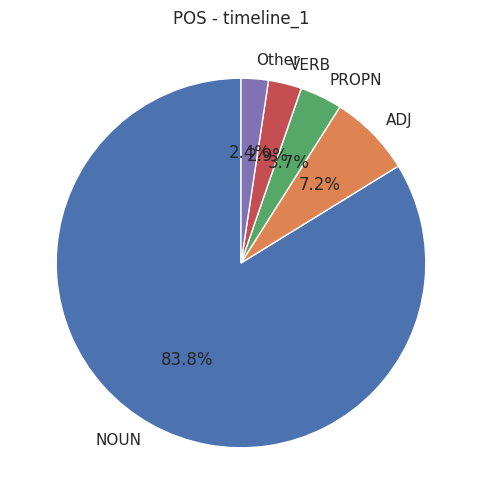

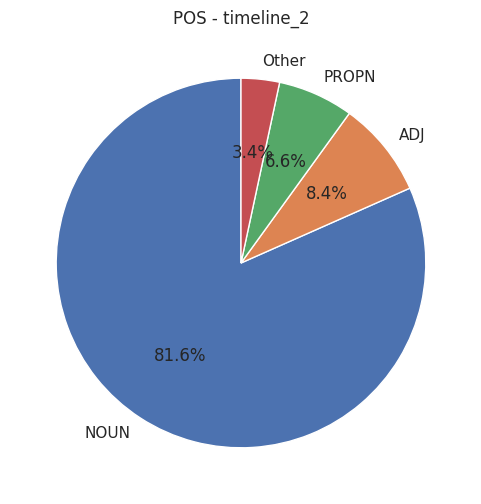

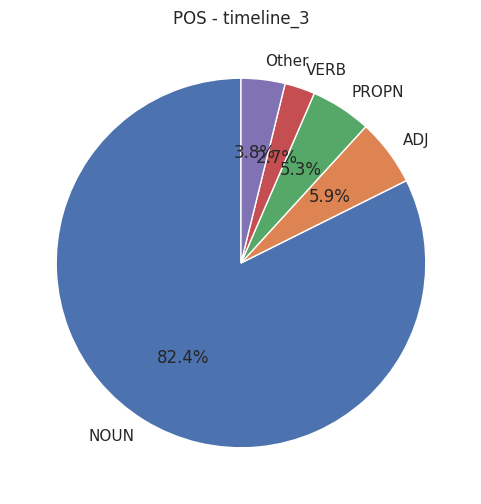

In [ ]:
# POS percentage 
tl_pos_counts = {tl: Counter() for tl in TOP_WORDS_PRE_TL}

for tl, top_words in TOP_WORDS_PRE_TL.items():
    for word in top_words:
        for text in word_samples[word]:
            tagged = text_to_pos.get(text, [])
            for w, tag in tagged:
                if w == word:
                    tl_pos_counts[tl][tag] += 1

# Convert to prct 
for tl, cnt in tl_pos_counts.items():
    total = sum(cnt.values())
    if total == 0:
        print(f'{tl}: no POS')
        continue

    tags_sorted = cnt.most_common()
    pos_dist = {}
    other = 0

    for tag, count in tags_sorted:
        pct = count / total * 100
        if pct < 2:
            other += count
        else:
            pos_dist[tag] = pct
        
    if other > 0:
        pos_dist['Other'] = other / total * 100

    # Plot pie chart
    plt.figure(figsize = (6, 6))
    labels = [reshape_persian(tag) for tag in pos_dist.keys()]
    plt.pie(pos_dist.values(), labels = labels, autopct = '%1.1f%%', startangle = 90)
    plt.title(f'POS - {tl}')
    plt.show()

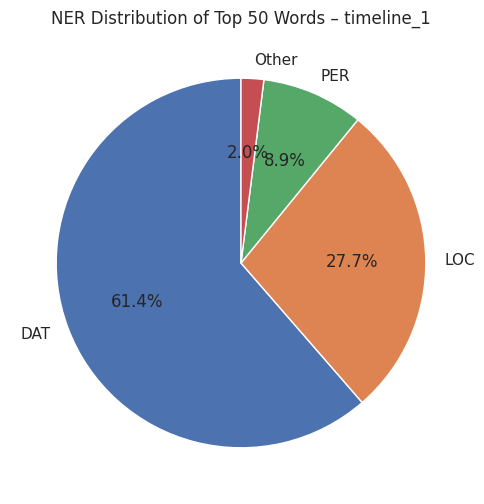

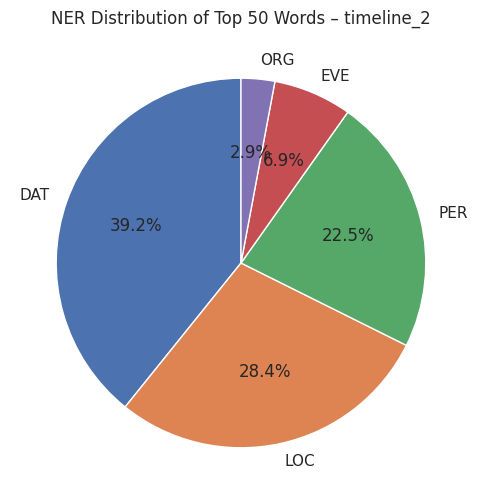

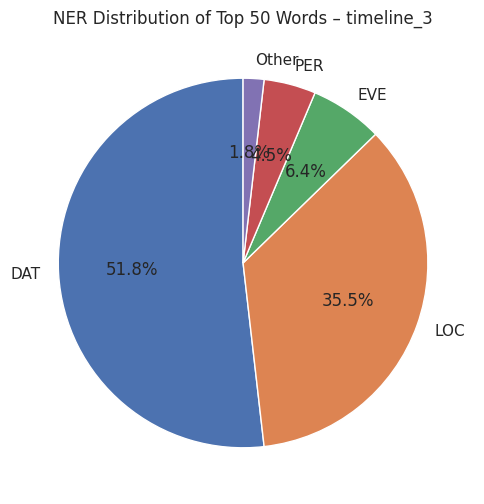

In [61]:
tl_ner_counts = {tl: Counter() for tl in TOP_WORDS_PRE_TL}

for tl, top_words in TOP_WORDS_PRE_TL.items():
    for word in top_words:
        for text in word_samples[word]:
            entities = text_to_ner.get(text, [])
            for ent_text, label in entities:
                if word in ent_text.split():
                    tl_ner_counts[tl][label] += 1

# Convert to percentage per timeline
for tl, cnt in tl_ner_counts.items():
    total = sum(cnt.values())
    if total == 0:
        print(f"{tl}: no NER data")
        continue
    tags_sorted = cnt.most_common()
    ner_dist = {}
    other = 0
    for tag, count in tags_sorted:
        pct = count / total * 100
        if pct < 2:
            other += count
        else:
            ner_dist[tag] = pct
    if other > 0:
        ner_dist['Other'] = other / total * 100
    plt.figure(figsize=(6,6))
    labels = [reshape_persian(tag) if tag in ['PER','ORG','LOC'] else tag for tag in ner_dist.keys()]
    plt.pie(ner_dist.values(), labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title(f'NER Distribution of Top 50 Words – {tl}')
    plt.show()

In [64]:
# Bigrams
def get_ngrams_counter(tokens_series, n = 1):
    cnt = Counter()
    for tokens in tokens_series:
        if len(tokens) >= n:
            cnt.update(ngrams(tokens, n))

    return cnt

# Plot func
def plot_top_ngrams(counter, n = 15, title = 'Top N-grams', color = 'teal'):
    top = counter.most_common(n)
    if not top:
        print('No data to plot')
        return
    grams, freqs = zip(*top)
    grams_reshaped = [reshape_persian(' '.join(g)) if isinstance(g, tuple) else reshape_persian(g) for g in grams]

    plt.barh(grams_reshaped, freqs, color = color)
    plt.title(title)
    plt.xlabel('Frequency')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


--- timeline_1 ---


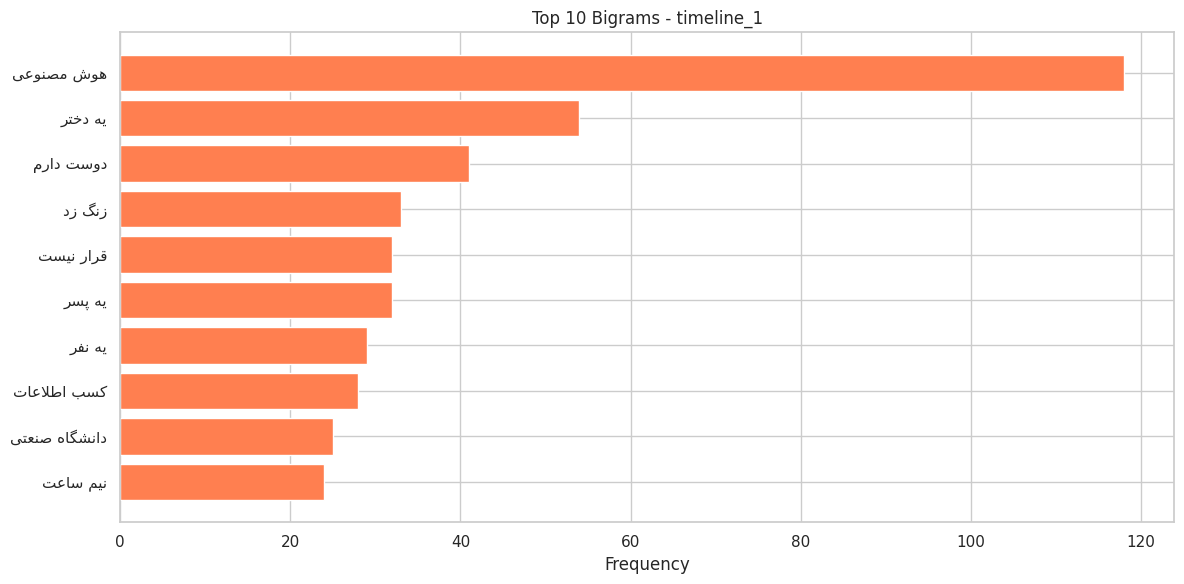


--- timeline_2 ---


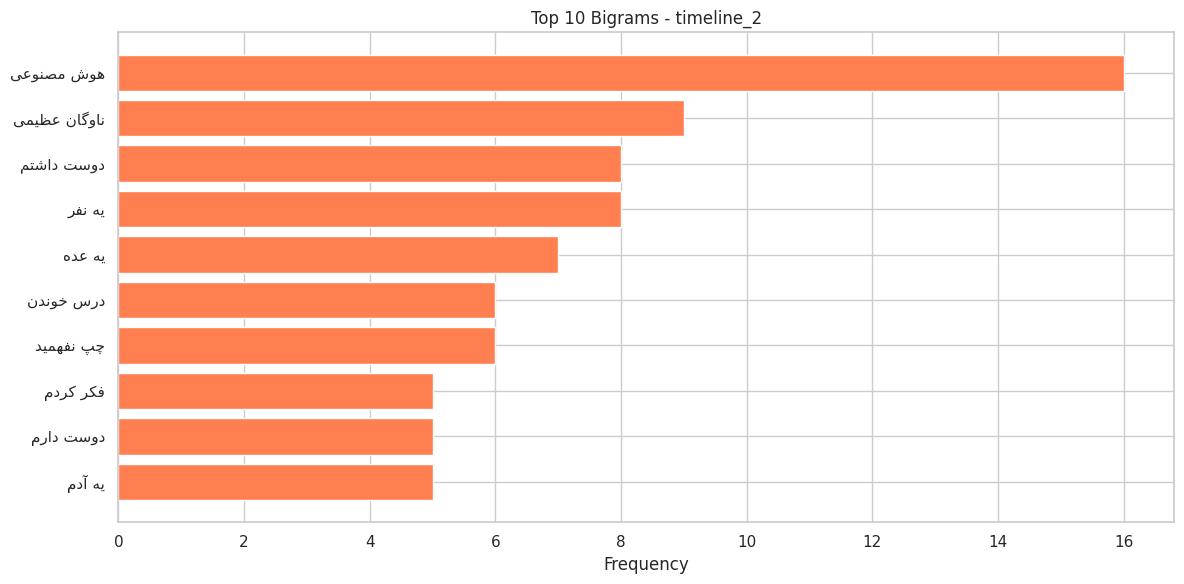


--- timeline_3 ---


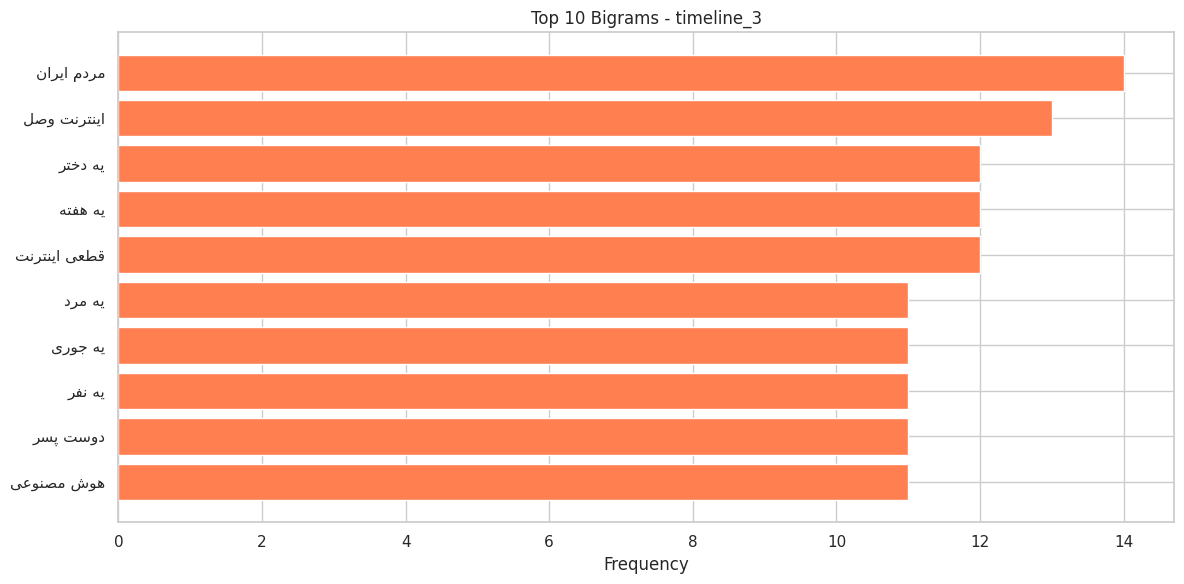

In [74]:
# Plot the most common Bigrams
for tl in sorted(df['timeline'].unique()):
    tdf = df[df['timeline'] == tl]
    print(f'\n--- {tl} ---')
    bigram_cnt = get_ngrams_counter(tdf['final_tokens_freq_not_stemmed'], n = 2)
    plot_top_ngrams(bigram_cnt, n = 10, title = f'Top 10 Bigrams - {tl}', color = 'coral')